In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import yfinance as yf
from datetime import datetime as dt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow import keras
from keras.models import Sequential
from keras.layers import *
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import SGD, Adam


import warnings
warnings.filterwarnings("ignore")

In [ ]:
coin_list = ["BTC-USD"]
coin_df = pd.DataFrame()

end = dt.strptime("2023/08/01", "%Y/%m/%d")
start = dt(end.year-4, end.month, end.day)

for coin in coin_list:
  temp = yf.download(coin, start, end)
  temp['ticker'] = coin
  coin_df = pd.concat([coin_df, temp])

coin_df["name"] = coin_df["ticker"].map({"BTC-USD": "Bitcoin"})
coin_df.drop(columns="ticker", inplace=True)
coin_df.head(6)

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume,name
Date,,,,,,,
2019-08-01,10077.442383,10446.919922,9922.019531,10399.668945,10399.668945,17165337858,Bitcoin
2019-08-02,10402.042969,10657.953125,10371.013672,10518.174805,10518.174805,17489094082,Bitcoin
2019-08-03,10519.278320,10946.781250,10503.504883,10821.726562,10821.726562,15352685061,Bitcoin
2019-08-04,10821.632812,11009.207031,10620.278320,10970.184570,10970.184570,16530894787,Bitcoin
2019-08-05,10960.735352,11895.091797,10960.735352,11805.653320,11805.653320,23875988832,Bitcoin
2019-08-06,11811.544922,12273.821289,11290.731445,11478.168945,11478.168945,23635107660,Bitcoin


In [ ]:
# summary
coin_df.info()
plt.tight_layout()
# missing values
coin_df.groupby("name").agg(lambda x: x.isna().sum()).sum(axis=1)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1461 entries, 2019-08-01 to 2023-07-31
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1461 non-null   float64
 1   High       1461 non-null   float64
 2   Low        1461 non-null   float64
 3   Close      1461 non-null   float64
 4   Adj Close  1461 non-null   float64
 5   Volume     1461 non-null   int64  
 6   name       1461 non-null   object 
dtypes: float64(5), int64(1), object(1)
memory usage: 91.3+ KB


name
Bitcoin    0
dtype: int64

<Figure size 640x480 with 0 Axes>

# **Visualization**

## Original Price Data



<Figure size 2000x1000 with 0 Axes>

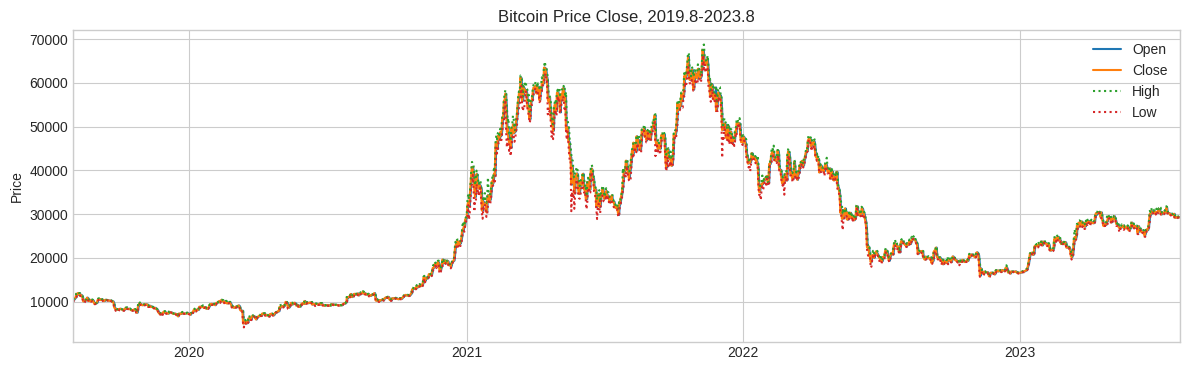

In [ ]:
plt.style.use("seaborn-whitegrid")
plt.figure(figsize=(20,10))
plt.subplots


plt.figure(figsize=(12,4))
coin_df['Open'].plot(label="Open")
coin_df['Close'].plot(label="Close")
coin_df['High'].plot(label="High", linestyle=':')
coin_df['Low'].plot(label="Low", linestyle=':')

plt.ylabel('Price')
plt.xlabel(' ')
plt.title("Bitcoin Price Close, 2019.8-2023.8")
plt.legend(loc='upper right')

plt.tight_layout()

## Scaled Price Data


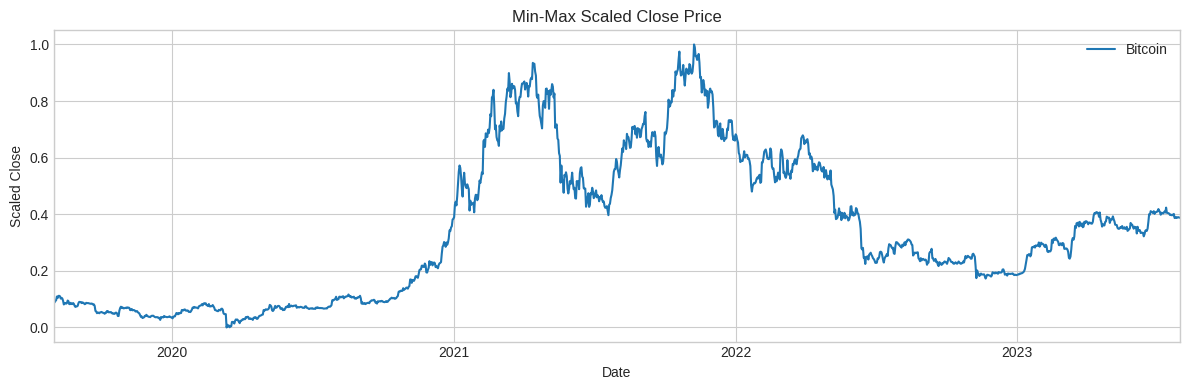

In [ ]:
# visualization of re-scaled data using min-max scaler

def min_max_scaler(data):
  scaler = MinMaxScaler(feature_range=(0,1))
  try:
    return scaler.fit_transform(data)
  except:
    return scaler.fit_transform(data.values.reshape(-1,1))

scaled_df = coin_df[['Close', 'name']]

scaled_btc = min_max_scaler(coin_df["Close"][coin_df["name"]=="Bitcoin"])
scaled_df['Close'][scaled_df.name == "Bitcoin"] = scaled_btc.reshape(-1,)



plt.figure(figsize=(12,4))

scaled_df['Close'].plot(label="Bitcoin")
plt.xlabel("Date")
plt.ylabel("Scaled Close")
plt.legend()
plt.title("Min-Max Scaled Close Price")

plt.tight_layout()

# **Preprocessing**

In [ ]:
# Split data into 3 folds: training set, testing set and validation set;
# model will first be trained on training and testing set;
# validation set used to evaluate its practical performance

def get_Xy(X_data, y_data, n):

  if len(X_data) != len(y_data): # X and y data should have same size
    raise ValueError("Incorrect input size!")

  X = []
  y = []

  for i in range(len(X_data)-n):
    X.append(X_data[i:i+n])
    y.append(y_data[i+n])

  X = np.array(X)
  print(X.shape)
  # X = np.reshape(X, (X.shape[0], X.shape[1], 1)) # reshape X data to be fed into LSTM model
  y = np.array(y)

  return X, y



def set_split(data, test_size=100, valid_size=100, window_size=60, get_unused=False):

  N = data.shape[0]
  test_size += window_size # in addition to the 100 data, we need an additional 60 as input data
  valid_size += window_size

  test_set = data[N-valid_size:]
  valid_set = data[N-valid_size-test_size:N-valid_size]
  train_set = data[:N-valid_size-test_size-window_size]

  return train_set, valid_set, test_set




# features we will be using for X and y
feature_name = ["Open", "Volume", "Close", "High", "Low", "Close"]
n_feature = len(feature_name)


# bitcoin data
btc_train_Xy, btc_valid_Xy, btc_test_Xy = set_split(coin_df[feature_name])


# scale data using Min-Max scaler
# first fit a scaler on training data, then fit to testing and validation set

btc_scaler = MinMaxScaler(feature_range=(0,1))

btc_train_Xy = btc_scaler.fit_transform(btc_train_Xy)
btc_valid_Xy = btc_scaler.transform(btc_valid_Xy)
btc_test_Xy = btc_scaler.transform(btc_test_Xy)


# create the input and output matrix/vector for LSTM
X_train, y_train = get_Xy(X_data = btc_train_Xy[:,:-1], y_data = btc_train_Xy[:,-1], n=60) # last column as target, the others as input predictors
X_valid, y_valid = get_Xy(X_data = btc_valid_Xy[:,:-1], y_data = btc_valid_Xy[:,-1], n=60)
X_test, y_test = get_Xy(X_data = btc_test_Xy[:,:-1], y_data = btc_test_Xy[:,-1], n=60)


(1021, 60, 5)
(100, 60, 5)
(100, 60, 5)


In [ ]:
print("In total, we have {0} data for training, {1} data for validation/parameter tuning and {2} data for testing.".format(len(X_train), len(X_valid), len(X_test)))

In total, we have 1021 data for training, 100 data for validation/parameter tuning and 100 data for testing.


## Data Split

Text(0.5, 1.0, 'Data Split - Scaled Bitcoin Close Price')

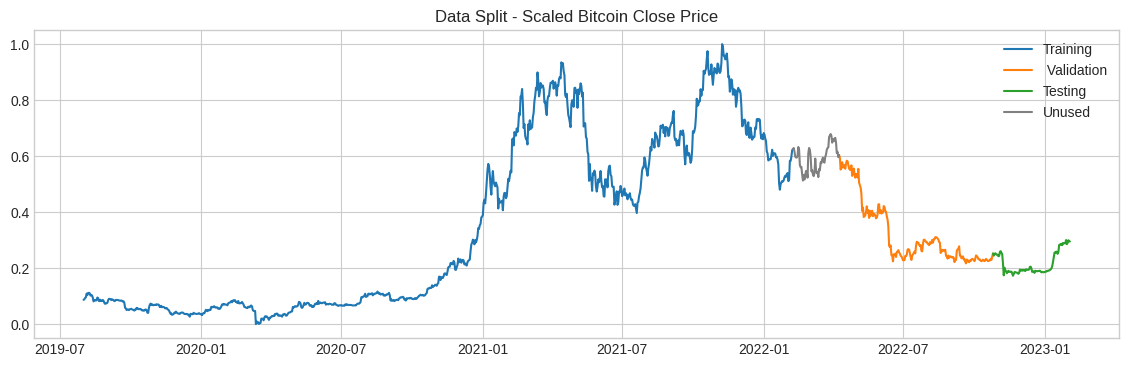

In [ ]:
plt.figure(figsize=(14,4))

scaled_btc_df = scaled_df[scaled_df.name=="Bitcoin"]

plt.plot(scaled_df.Close[:923], label="Training")
plt.plot(scaled_df.Close[982:1183], label=" Validation")
plt.plot(scaled_df.Close[1182:1283], label="Testing")
plt.plot(scaled_df.Close[922:983], label="Unused", color='grey')

plt.legend()
plt.title("Data Split - Scaled Bitcoin Close Price")

# **Model**

# Multi-Feature LSTM

Our goal is to make predictions for Bitcoin close price in the next day, given the data from the past 60 days. The model we consider will account for 5 features as predictors: close, open, high, low, and lastly, trading volume. The outcome of interest will be the close price. In our model, we will use LSTM architecture on top of the RNN framework, which is provided by Tensorflow Keras. Since we are dealing with continuous outcome, we will consider mean squared error as our loss function. For now, we will use Adam as our optimizer. We have also tried with stochatic gradient descent, which has very slow convergence rate and is not as efficient as Adam.

In [ ]:
lstm_model = Sequential()
lstm_model.add(LSTM(units = 50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
lstm_model.add(LSTM(units = 50, return_sequences=False))
lstm_model.add(Dense(25))
lstm_model.add(Dense(1))


lstm_model.summary()
lstm_model.compile(optimizer = Adam(learning_rate=0.01), loss = MeanSquaredError(), metrics=[RootMeanSquaredError()])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 50)            11200     
                                                                 
 lstm_1 (LSTM)               (None, 50)                20200     
                                                                 
 dense (Dense)               (None, 25)                1275      
                                                                 
 dense_1 (Dense)             (None, 1)                 26        
                                                                 
Total params: 32701 (127.74 KB)
Trainable params: 32701 (127.74 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


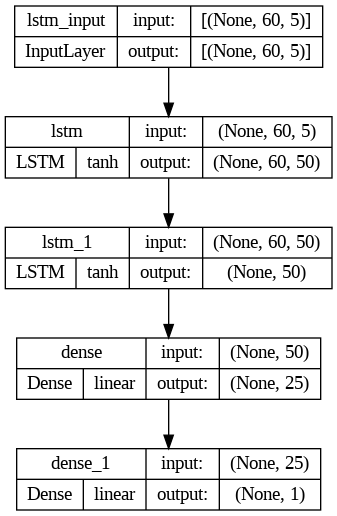

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(lstm_model, show_shapes=True, show_layer_activations=True)

### Comment

Our model consists of 4 layers, with 2 LSTM layers (each has 50 units) and 2 dense layer (including one with 25 units and 1 output layer). The activation functions are set identical across LSTM layers and across Dense layers. For dense layers, linear activation function is adopted. For LSTM, sigmoid and hyperbolic tangent are used as activation functions for internal gates and cell states, respectively. The first LSTM layer will take input of a 60-by-5 sequence of data (60 days, with 5 features); the output of this layers is also going to be a sequence with length of 60. This is then fed into the dense layer, and eventually everything gets compressed into a 1-unit output.

## Training

In [ ]:
history1 = lstm_model.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=50)

Epoch 1/50
32/32 [==============================] - 8s 109ms/step - loss: 0.0368 - root_mean_squared_error: 0.1918 - val_loss: 9.5478e-04 - val_root_mean_squared_error: 0.0309
Epoch 2/50
32/32 [==============================] - 3s 97ms/step - loss: 0.0030 - root_mean_squared_error: 0.0548 - val_loss: 3.8370e-04 - val_root_mean_squared_error: 0.0196
Epoch 3/50
32/32 [==============================] - 2s 70ms/step - loss: 0.0016 - root_mean_squared_error: 0.0402 - val_loss: 3.0942e-04 - val_root_mean_squared_error: 0.0176
Epoch 4/50
32/32 [==============================] - 2s 63ms/step - loss: 0.0014 - root_mean_squared_error: 0.0375 - val_loss: 1.7118e-04 - val_root_mean_squared_error: 0.0131
Epoch 5/50
32/32 [==============================] - 2s 63ms/step - loss: 0.0012 - root_mean_squared_error: 0.0348 - val_loss: 1.5343e-04 - val_root_mean_squared_error: 0.0124
Epoch 6/50
32/32 [==============================] - 2s 66ms/step - loss: 0.0014 - root_mean_squared_error: 0.0368 - val_loss

In [ ]:
history1.history.keys()

dict_keys(['loss', 'root_mean_squared_error', 'val_loss', 'val_root_mean_squared_error'])

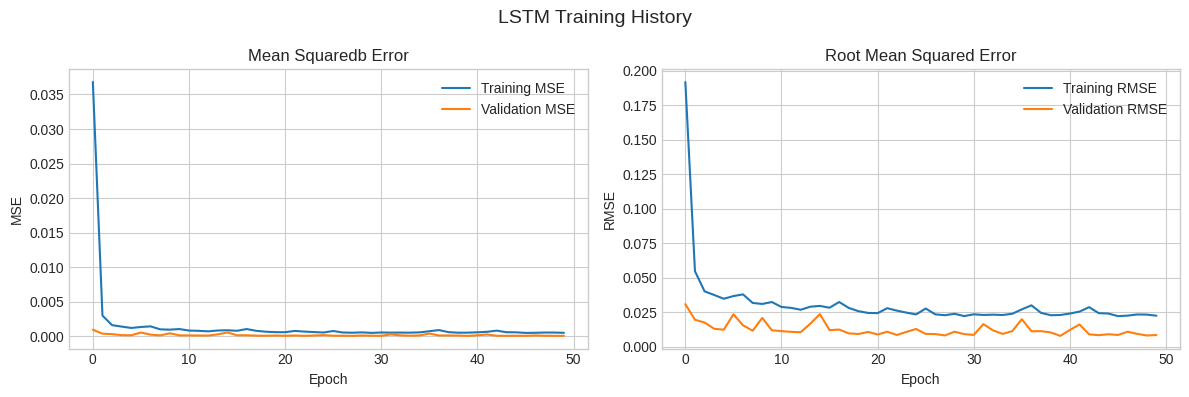

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(121)
plt.plot(history1.history['loss'], label = "Training MSE")
plt.plot(history1.history['val_loss'], label = "Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Mean Squaredb Error")
plt.legend()

plt.subplot(122)
plt.plot(history1.history['root_mean_squared_error'], label = "Training RMSE")
plt.plot(history1.history['val_root_mean_squared_error'], label = "Validation RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Root Mean Squared Error")
plt.legend()
plt.suptitle("LSTM Training History", fontsize=14)
plt.tight_layout()

We first train for 50 epochs. Upon visual inspection, the algorithm converges very quickly and we should have reached very close to the local minimum after 50 epochs. Interestingly, the validation MSE (RMSE) is actually consistently lower than training MSE (RMSE).

## Next-Day Prediction

After fitting the model, it would be nice to see the model's performance based on unseen data. The validation set was not used during model training, but it contains price data from at least 100 days after the last day in the training set. The prediction was made by utilizing the publically available market information; which includes open price, close price, high, low, and trading volume. The goal is to repeatedly predict the next day's close price for 100 days (roughly from 2023.5 to 2023.8). The results are presented below:

In [ ]:
def prediction_plot(actual, predicted, name = "Bitcoin"):

  plt.figure(figsize=(12,4))
  plt.plot(actual, label='Actual Price')
  plt.plot(predicted, label='Predicted Price')
  plt.title('Price Prediction for {0}'.format(name))
  plt.xlabel('Time Step')
  plt.ylabel('Scaled Close')
  plt.legend()

4/4 [==============================] - 0s 31ms/step


Text(0.5, 1.0, 'Bitcoin Next-Day Prediction: Testing Set')

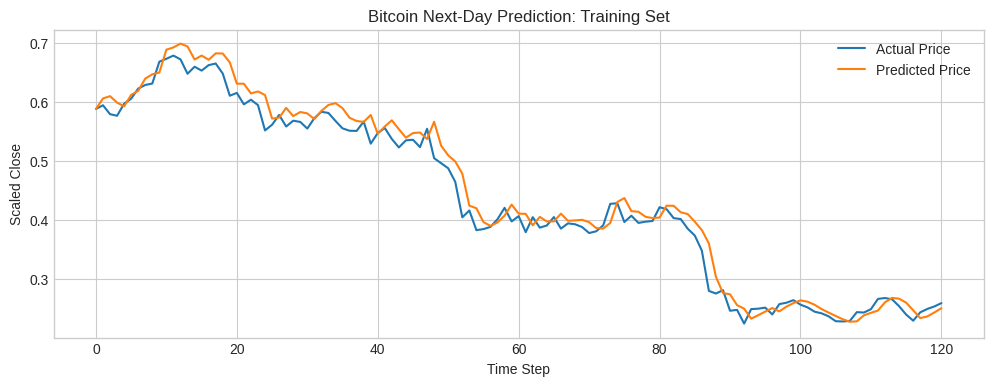

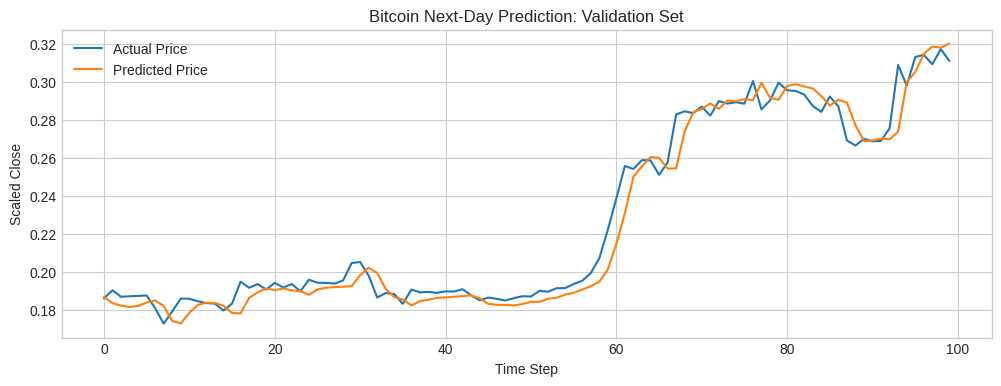

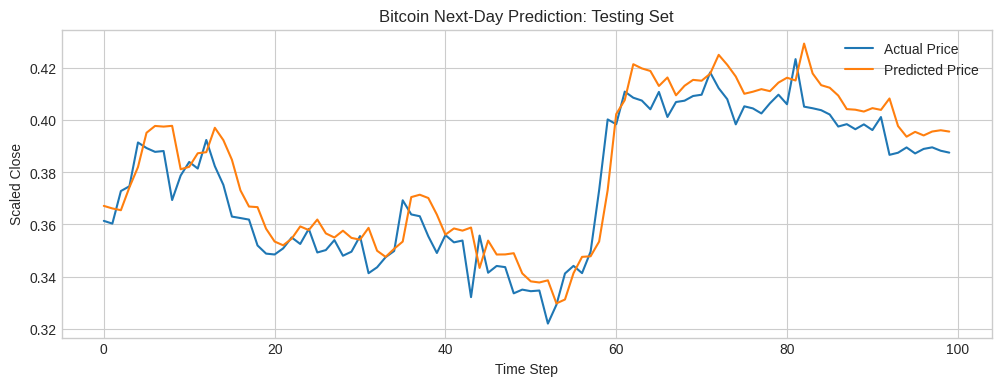

In [ ]:
multi_pred_train = lstm_model.predict(X_train)
prediction_plot(y_train[900:], multi_pred_train[900:])
plt.title("Bitcoin Next-Day Prediction: Training Set")

multi_pred_valid = lstm_model.predict(X_valid)
prediction_plot(y_valid, multi_pred_valid)
plt.title("Bitcoin Next-Day Prediction: Validation Set")

multi_pred_test = lstm_model.predict(X_test)
prediction_plot(y_test, multi_pred_test)
plt.title("Bitcoin Next-Day Prediction: Testing Set")

## Multi-Feature RNN

In [ ]:
RNN_model = keras.Sequential()


# Add the first SimpleRNN layer
RNN_model.add(keras.layers.SimpleRNN(units=64, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))

# Add additional SimpleRNN layers
RNN_model.add(keras.layers.SimpleRNN(units=64, activation='relu', return_sequences=False))
RNN_model.add(keras.layers.Dense(units=30))

# Add a Dense (fully connected) layer for the output
RNN_model.add(keras.layers.Dense(units=1, activation='linear'))  # Adjust units and activation as needed

RNN_model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_4 (SimpleRNN)    (None, 60, 64)            4480      
                                                                 
 simple_rnn_5 (SimpleRNN)    (None, 64)                8256      
                                                                 
 dense_10 (Dense)            (None, 30)                1950      
                                                                 
 dense_11 (Dense)            (None, 1)                 31        
                                                                 
Total params: 14717 (57.49 KB)
Trainable params: 14717 (57.49 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


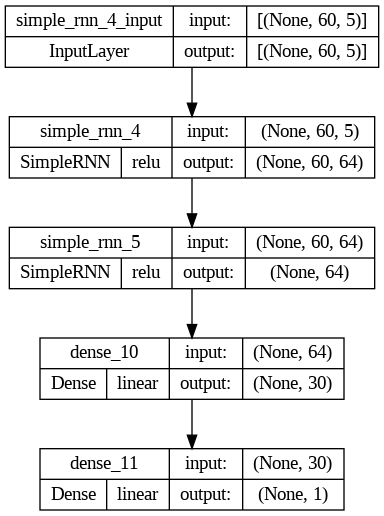

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(RNN_model, show_shapes=True, show_layer_activations=True)

In [ ]:
optimizer = keras.optimizers.Adam(learning_rate=0.01)  # Adjust clipvalue as needed
RNN_model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=[RootMeanSquaredError()])

history_rnn = RNN_model.fit(X_train, y_train, epochs=50, validation_data=(X_valid, y_valid))

Epoch 1/50
32/32 [==============================] - 4s 53ms/step - loss: 16.2523 - root_mean_squared_error: 4.0314 - val_loss: 0.0016 - val_root_mean_squared_error: 0.0402
Epoch 2/50
32/32 [==============================] - 2s 64ms/step - loss: 0.0012 - root_mean_squared_error: 0.0353 - val_loss: 9.7406e-05 - val_root_mean_squared_error: 0.0099
Epoch 3/50
32/32 [==============================] - 2s 55ms/step - loss: 6.8914e-04 - root_mean_squared_error: 0.0263 - val_loss: 1.5176e-04 - val_root_mean_squared_error: 0.0123
Epoch 4/50
32/32 [==============================] - 1s 35ms/step - loss: 8.4424e-04 - root_mean_squared_error: 0.0291 - val_loss: 7.5106e-05 - val_root_mean_squared_error: 0.0087
Epoch 5/50
32/32 [==============================] - 1s 36ms/step - loss: 6.2505e-04 - root_mean_squared_error: 0.0250 - val_loss: 7.4537e-05 - val_root_mean_squared_error: 0.0086
Epoch 6/50
32/32 [==============================] - 1s 34ms/step - loss: 6.5863e-04 - root_mean_squared_error: 0.025

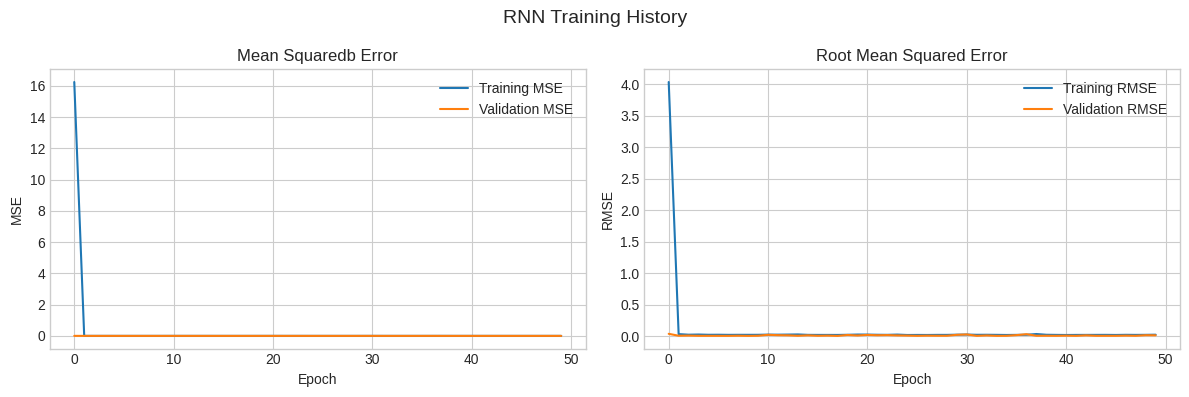

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(121)
plt.plot(history_rnn.history['loss'], label = "Training MSE")
plt.plot(history_rnn.history['val_loss'], label = "Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Mean Squaredb Error")
plt.legend()

plt.subplot(122)
plt.plot(history_rnn.history['root_mean_squared_error'], label = "Training RMSE")
plt.plot(history_rnn.history['val_root_mean_squared_error'], label = "Validation RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Root Mean Squared Error")
plt.legend()
plt.suptitle("RNN Training History", fontsize=14)
plt.tight_layout()

4/4 [==============================] - 0s 16ms/step


Text(0.5, 1.0, 'Bitcoin Next-Day Prediction: Testing Set')

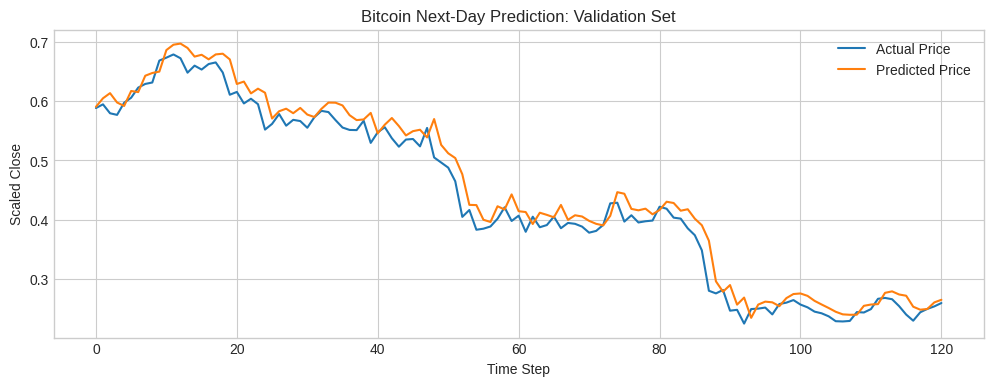

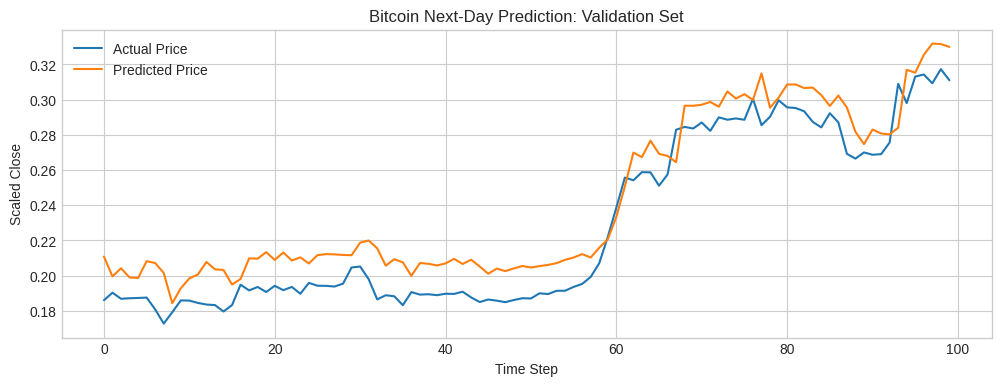

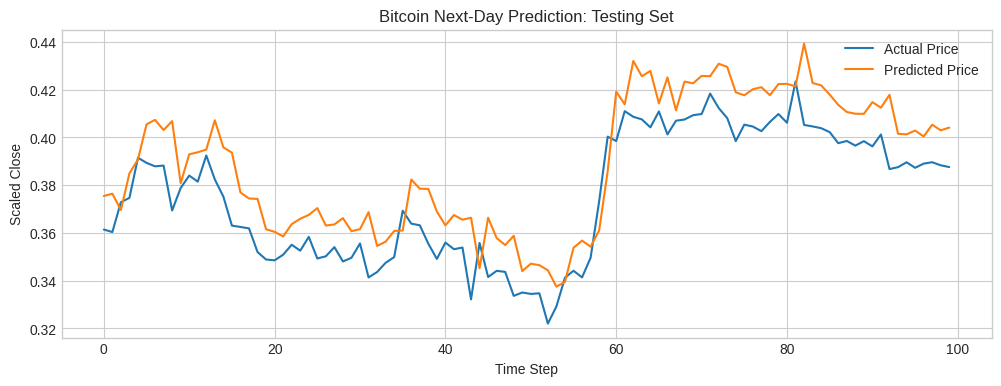

In [ ]:
rnn_pred_train = RNN_model.predict(X_train)
prediction_plot(y_train[900:], rnn_pred_train[900:])
plt.title("Bitcoin Next-Day Prediction: Validation Set")


rnn_pred_valid = RNN_model.predict(X_valid)
prediction_plot(y_valid, rnn_pred_valid)
plt.title("Bitcoin Next-Day Prediction: Validation Set")

rnn_pred_test = RNN_model.predict(X_test)
prediction_plot(y_test, rnn_pred_test)
plt.title("Bitcoin Next-Day Prediction: Testing Set")

# Single-Feature LSTM

Now that we did our prediction using the 5 input features aforementioned. For the next step, we will use only the close price from the last 60 days to predict the close price for the next day. We use the same model structure, and simply changed the input layer a little bit (now input dimension is (60, 1) rather than (60,5)). The results are presented below.

In [ ]:
# create the input and output matrix/vector for LSTM
X_train, y_train = get_Xy(X_data = btc_train_Xy[:,-1], y_data = btc_train_Xy[:,-1], n=60)  # last column as target, the others as input predictors
X_test, y_test = get_Xy(X_data = btc_test_Xy[:,-1], y_data = btc_test_Xy[:,-1], n=60)
X_valid, y_valid = get_Xy(X_data = btc_valid_Xy[:,-1], y_data = btc_valid_Xy[:,-1], n=60)

(1021, 60)
(100, 60)
(100, 60)


In [ ]:
lstm_model2 = Sequential()
lstm_model2.add(LSTM(units = 50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
lstm_model2.add(LSTM(units = 50, return_sequences=False))
lstm_model2.add(Dense(25))
lstm_model2.add(Dense(1))


lstm_model2.summary()
lstm_model2.compile(optimizer = Adam(learning_rate=0.01), loss = MeanSquaredError(), metrics=[RootMeanSquaredError()])

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 60, 50)            10400     
                                                                 
 lstm_3 (LSTM)               (None, 50)                20200     
                                                                 
 dense_4 (Dense)             (None, 25)                1275      
                                                                 
 dense_5 (Dense)             (None, 1)                 26        
                                                                 
Total params: 31901 (124.61 KB)
Trainable params: 31901 (124.61 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


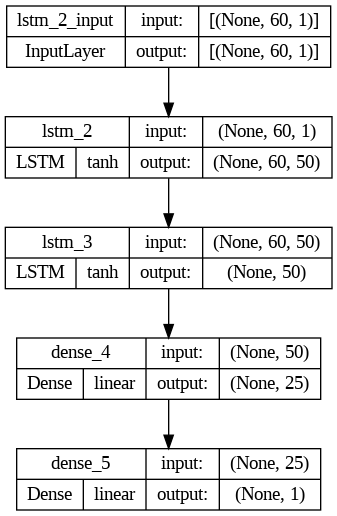

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(lstm_model2, show_shapes=True, show_layer_activations=True)

In [ ]:
history2 = lstm_model2.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=50)

Epoch 1/50
32/32 [==============================] - 9s 104ms/step - loss: 0.0282 - root_mean_squared_error: 0.1678 - val_loss: 0.0027 - val_root_mean_squared_error: 0.0517
Epoch 2/50
32/32 [==============================] - 2s 67ms/step - loss: 0.0020 - root_mean_squared_error: 0.0444 - val_loss: 7.1536e-04 - val_root_mean_squared_error: 0.0267
Epoch 3/50
32/32 [==============================] - 2s 62ms/step - loss: 0.0015 - root_mean_squared_error: 0.0381 - val_loss: 3.0853e-04 - val_root_mean_squared_error: 0.0176
Epoch 4/50
32/32 [==============================] - 3s 89ms/step - loss: 0.0012 - root_mean_squared_error: 0.0352 - val_loss: 1.5998e-04 - val_root_mean_squared_error: 0.0126
Epoch 5/50
32/32 [==============================] - 2s 73ms/step - loss: 0.0011 - root_mean_squared_error: 0.0325 - val_loss: 1.1774e-04 - val_root_mean_squared_error: 0.0109
Epoch 6/50
32/32 [==============================] - 2s 63ms/step - loss: 0.0010 - root_mean_squared_error: 0.0316 - val_loss: 3.

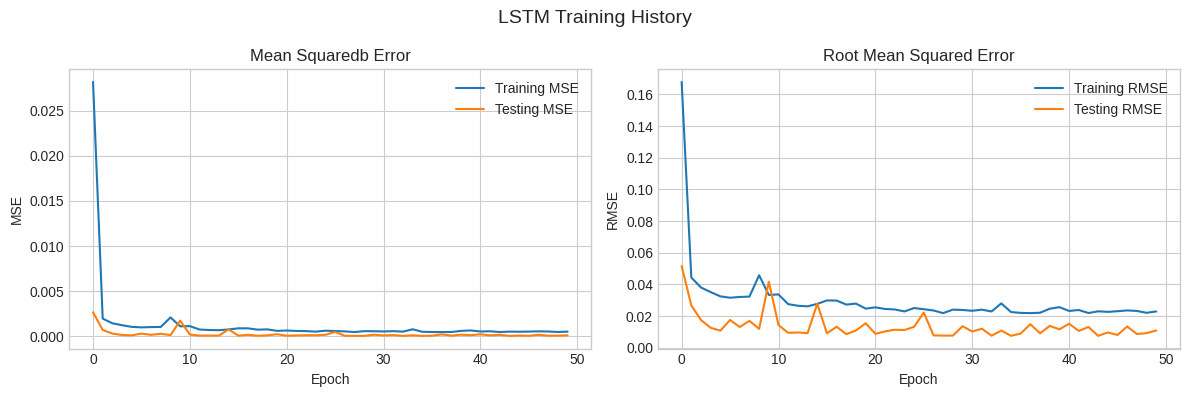

In [ ]:

plt.figure(figsize=(12,4))

plt.subplot(121)
plt.plot(history2.history['loss'], label = "Training MSE")
plt.plot(history2.history['val_loss'], label = "Testing MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Mean Squaredb Error")
plt.legend()

plt.subplot(122)
plt.plot(history2.history['root_mean_squared_error'], label = "Training RMSE")
plt.plot(history2.history['val_root_mean_squared_error'], label = "Testing RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Root Mean Squared Error")
plt.legend()
plt.suptitle("LSTM Training History", fontsize=14)
plt.tight_layout()

32/32 [==============================] - 1s 32ms/step


Text(0.5, 1.0, 'Bitcoin Next-Day Prediction: Training Set')

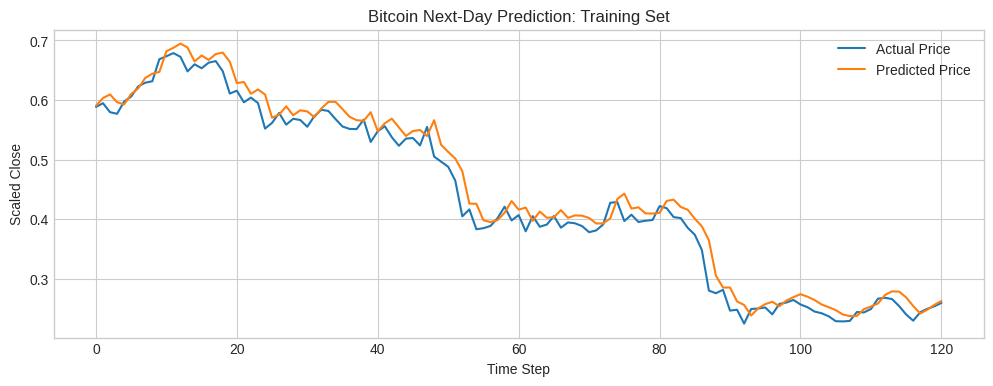

In [ ]:
single_pred_train = lstm_model2.predict(X_train)
prediction_plot(y_train[900:], single_pred_train[900:])
plt.title("Bitcoin Next-Day Prediction: Training Set")

Text(0.5, 1.0, 'Bitcoin Next-Day Prediction: Testing Set')

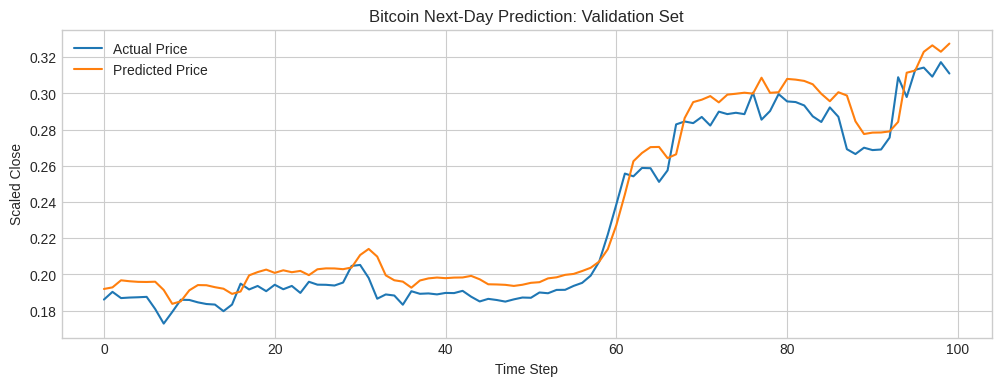

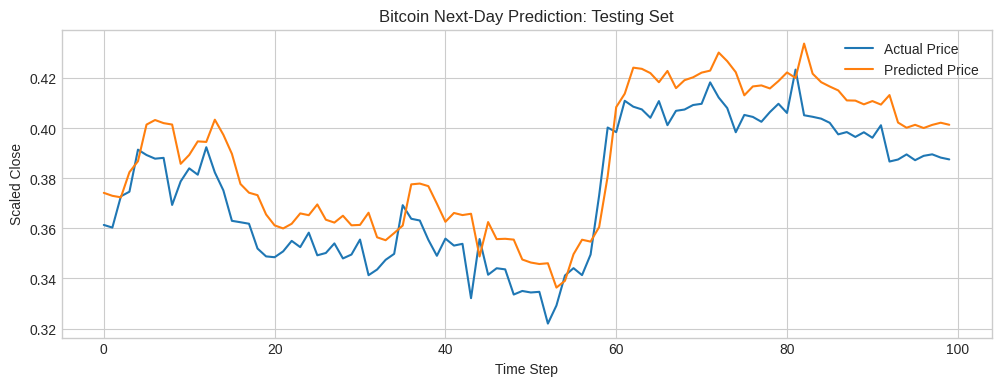

In [ ]:
prediction_plot(y_valid, single_pred_valid)
plt.title("Bitcoin Next-Day Prediction: Validation Set")

prediction_plot(y_test, single_pred_test)
plt.title("Bitcoin Next-Day Prediction: Testing Set")

## Next-Day Prediction

4/4 [==============================] - 0s 37ms/step


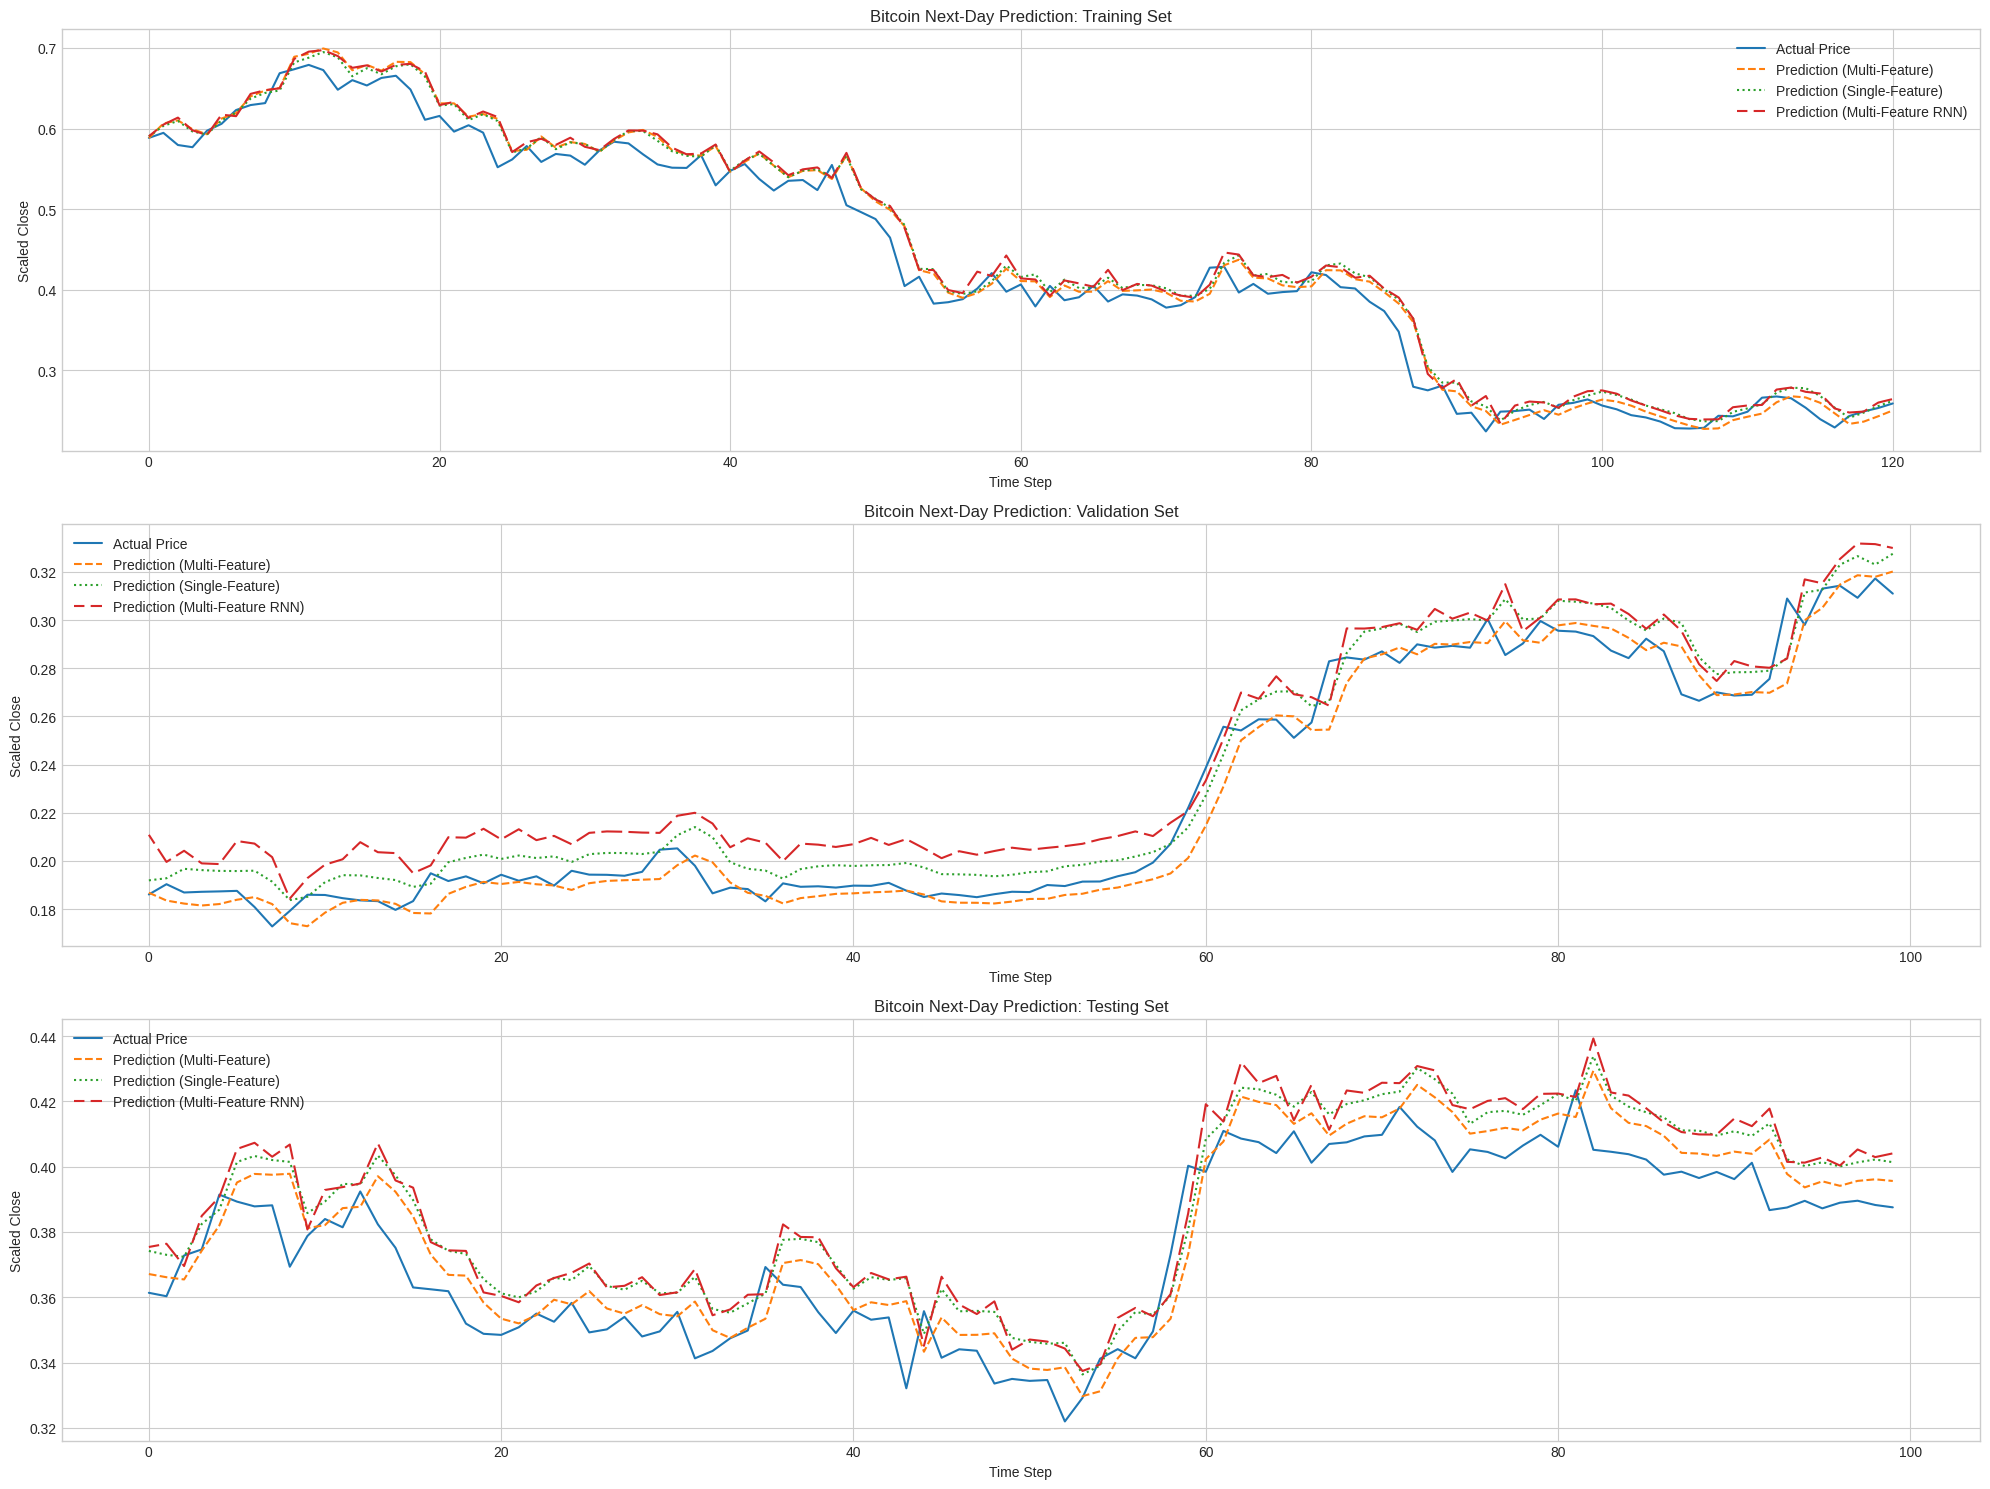

In [ ]:
single_pred_valid = lstm_model2.predict(X_valid)
single_pred_test = lstm_model2.predict(X_test)

plt.figure(figsize=(20,15))

plt.subplot(311)
plt.plot(y_train[900:], label="Actual Price")
plt.plot(multi_pred_train[900:], label="Prediction (Multi-Feature)", linestyle='dashed')
plt.plot(single_pred_train[900:], label="Prediction (Single-Feature)", linestyle='dotted')
plt.plot(rnn_pred_train[900:], label="Prediction (Multi-Feature RNN)", linestyle=(5,(10,3)))
plt.legend()
plt.xlabel("Time Step")
plt.ylabel("Scaled Close")
plt.title("Bitcoin Next-Day Prediction: Training Set")

plt.subplot(312)
plt.plot(y_valid, label="Actual Price")
plt.plot(multi_pred_valid, label="Prediction (Multi-Feature)", linestyle='dashed')
plt.plot(single_pred_valid, label="Prediction (Single-Feature)", linestyle='dotted')
plt.plot(rnn_pred_valid, label="Prediction (Multi-Feature RNN)", linestyle=(5,(10,3)))
plt.legend()
plt.xlabel("Time Step")
plt.ylabel("Scaled Close")
plt.title("Bitcoin Next-Day Prediction: Validation Set")

plt.subplot(313)
plt.plot(y_test, label="Actual Price")
plt.plot(multi_pred_test, label="Prediction (Multi-Feature)", linestyle='dashed')
plt.plot(single_pred_test, label="Prediction (Single-Feature)", linestyle='dotted')
plt.plot(rnn_pred_test, label="Prediction (Multi-Feature RNN)", linestyle=(5,(10,3)))
plt.legend()
plt.xlabel("Time Step")
plt.ylabel("Scaled Close")
plt.title("Bitcoin Next-Day Prediction: Testing Set")

plt.tight_layout()

### Comment

Here we combined and cross-compared the 3 types of models we have built so far. They are all quite like "initial guesses" and were not fine-tuned. As we expected, the multi-feature LSTM obviously performs better than its single-feature version in terms of how close the predicted price is to the actual price. The predicted curve from the RNN model looks very similar, if not exactly identical, to the multi-feature LSTM, even though deviates from the actual prices a little bit more than LSTM. A likely reason is that our model is not making use of information from the very past quite effectively (so that RNN and LSTM both put significantly more weights to the recent prices). Also, since both models share the same feature sets, it is not surprising to see such similarity.



## Model Optimization

In the below, we perform model optimization. (...more description on how...)

Note: We do parameter-tuning only for the multi-feature model for the sake of this project (since it looks more reliable).

Early-Stopping:

1. It can effectively finds the optimal number of epochs to use for training, which will prevent the model from overfitting.
2. It is a parameter-free regularization technique and intuitive to use.
3. We don't need to go over different number of epochs now (which is inefficient). The model will automatically call it a stop once the criteria are met.

How to Early-Stop:

Set minimum loss change (per epoch) to 1e-6 (this difference is calculated as the current loss value minus the best-monitored loss value until now). Previously the best model we trained achieved a best validation loss of roughly 5e-4. Ideally we want the delta to be below 1e-6, so that we set the minimum loss change to 1e-6. This is our convergence criterion. The model will keep training, and stops once the validation loss stops decreasing by more than 1e-8 from the best loss for 30 consecutive epochs.


Parameter Grid-Search was used as tool to find the best parameter combination. We used a randomized version of it as it's computationally hard to include all possible combinations. Specifically, we first built a custom Keras regressor, in which differeng parameters can be passed in as function argument. Then we uniformly randomly selected 100 combinations (without replacement) of parameters, calculated the loss, and produced a rank for all the 100 models based on testing loss.

For the LSTM unit, we have 2 activation functions that can be customized. The first one is


In [ ]:
min(history2.history['val_loss'])

4.275842911738437e-06

In [ ]:
!pip install scikeras

In [ ]:
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import PredefinedSplit


# create the input and output matrix/vector for LSTM
X_train, y_train = get_Xy(X_data = btc_train_Xy[:,:-1], y_data = btc_train_Xy[:,-1], n=60) # last column as target, the others as input predictors
X_valid, y_valid = get_Xy(X_data = btc_valid_Xy[:,:-1], y_data = btc_valid_Xy[:,-1], n=60)
X_test, y_test = get_Xy(X_data = btc_test_Xy[:,:-1], y_data = btc_test_Xy[:,-1], n=60)


X_train_valid = np.concatenate((X_train, X_valid),axis=0) # this combines X_train and X_valid
y_train_valid = np.concatenate((y_train, y_valid),axis=0) # this combines y_train and y_valid



# split_ind is an array of indicators where it's 1 if the data belongs to training set and 0 otherwise
split_ind = np.append(-1*np.ones(X_train.shape[0], dtype=np.int8), np.zeros(X_valid.shape[0], dtype=np.int8))
pds = PredefinedSplit(split_ind)



# define the model

def create_model(n_lstm = 2, size_lstm = 128, lr = 0.01,
                 optimizer = "Adam", lstm_activation = "tanh", lstm_activation2 = "sigmoid",
                 dense_activation = "linear", pooling = False):
    # initialize
    size_dense = size_lstm

    model = Sequential()
    model.add(InputLayer(input_shape=(X_train.shape[1],X_train.shape[2])))


    if pooling == False:

        for _ in range(0, n_lstm):
            if _ + 1 < n_lstm:
                # if this is intermediate LSTM layer, return sequences
                model.add(LSTM(units=size_lstm // (2**_), activation = lstm_activation,
                               recurrent_activation = lstm_activation2,
                               return_sequences=True))
                size_dense = size_dense // (2**_)

            else:
                # if this is the last LSTM layer, return the final hidden state instead of the whole seq
                model.add(LSTM(units=size_lstm // (2**_), activation = lstm_activation,
                               recurrent_activation = lstm_activation2,
                               return_sequences=False))
                size_dense = size_dense // (2**_)

        model.add(Dense(size_dense, activation = dense_activation))
        model.add(Dense(20, activation = dense_activation))
        model.add(Dense(1, activation = dense_activation))

    if pooling == True:

        for _ in range(0, n_lstm):
            model.add(LSTM(units=size_lstm // (2**_), activation = lstm_activation,
                           recurrent_activation = lstm_activation2,
                           return_sequences=True))
            size_dense = size_dense // (2**_)

        model.add(GlobalAveragePooling1D(data_format="channels_last")) # input size is (batch, steps, features)
        model.add(Dense(size_dense, activation = dense_activation))
        model.add(Dense(20, activation = dense_activation))
        model.add(Dense(1, activation = dense_activation))



    if optimizer == "Adam":
        model.compile(optimizer=Adam(learning_rate=lr), loss = MeanSquaredError(), metrics=[RootMeanSquaredError()])

    print(lstm_activation)
    return model

opt_model = KerasRegressor(build_fn=create_model,
                          lr = 0.01,
                          size_lstm = 128,
                          n_lstm = 2,
                          lstm_activation = "tanh",
                          lstm_activation2 = "sigmoid",
                          dense_activation = "linear",
                          pooling = False)



# this is to first find the optimal sets of activation functions
param_grid0 = {
    'lstm_activation': ['tanh', 'relu', 'sigmoid'],
    'lstm_activation2': ['tanh', 'relu', 'sigmoid'],
    'dense_activation': ['relu', 'linear', 'sigmoid'],
    'size_lstm': [32],
    'n_lstm': [1],
    'pooling': [False],
    'lr': [0.01],
    'epochs': [50]
}



param_grid1 = {
    'lstm_activation': ['tanh'],
    'lstm_activation2': ['sigmoid'],
    'dense_activation': ['linear', 'sigmoid'],
    'size_lstm': [32, 64, 128, 256],
    'n_lstm': [1, 2, 3],
    'pooling': [True, False],
    'lr': [0.01, 0.001, 0.0005, 0.0001],
    'epochs': [50, 100, 500]
}

(1021, 60, 5)
(100, 60, 5)
(100, 60, 5)


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

updated_model0 = RandomizedSearchCV(opt_model, param_grid0, cv=pds, n_iter=27, n_jobs=-1, refit=False,
                                  return_train_score=True, scoring="neg_mean_squared_error", verbose=4)
updated_model0.fit(X_train_valid, y_train_valid)

Fitting 1 folds for each of 27 candidates, totalling 27 fits


RandomizedSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ...,  0,  0])),
                   estimator=KerasRegressor(build_fn=<function create_model at 0x77ffe025e950>, dense_activation='linear', lr=0.01, lstm_activation='tanh', lstm_activation2='sigmoid', n_lstm=2, pooling=False, size_lstm=128),
                   n_iter=27, n_jobs=-1,
                   param_distributions={'dense_activation': ['relu', 'linear',
                                                             'sigmoid'],
                                        'epochs': [50], 'lr': [0.01],
                                        'lstm_activation': ['tanh', 'relu',
                                                            'sigmoid'],
                                        'lstm_activation2': ['tanh', 'relu',
                                                             'sigmoid'],
                                        'n_lstm': [1], 'pooling': [False],
                                        'size_lstm': [32]},
                   refit=False, return_train_score=True,
                   scoring='neg_mean_squared_error', verbose=4)

In [ ]:
param_result0.to_csv("param0.csv")

In [ ]:
param_result0 = pd.DataFrame(updated_model0.cv_results_)
param_result0[param_result0.rank_test_score == 1]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_size_lstm,param_pooling,param_n_lstm,param_lstm_activation2,param_lstm_activation,param_lr,param_epochs,param_dense_activation,params,split0_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,mean_train_score,std_train_score
16,264.130543,0.0,0.413145,0.0,32,False,1,relu,sigmoid,0.01,50,linear,"{'size_lstm': 32, 'pooling': False, 'n_lstm': ...",-0.000058,-0.000058,0.0,1,-0.000449,-0.000449,0.0


In [ ]:
param_result0[param_result0.rank_test_score == 2]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_size_lstm,param_pooling,param_n_lstm,param_lstm_activation2,param_lstm_activation,param_lr,param_epochs,param_dense_activation,params,split0_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,mean_train_score,std_train_score
20,38.226204,0.0,0.905435,0.0,32,False,1,sigmoid,tanh,0.01,50,sigmoid,"{'size_lstm': 32, 'pooling': False, 'n_lstm': ...",-0.000076,-0.000076,0.0,2,-0.000657,-0.000657,0.0


In [ ]:
param_result0[param_result0.rank_test_score == 4]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_size_lstm,param_pooling,param_n_lstm,param_lstm_activation2,param_lstm_activation,param_lr,param_epochs,param_dense_activation,params,split0_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,mean_train_score,std_train_score
14,264.399192,0.0,0.482925,0.0,32,False,1,sigmoid,relu,0.01,50,linear,"{'size_lstm': 32, 'pooling': False, 'n_lstm': ...",-0.000082,-0.000082,0.0,4,-0.000475,-0.000475,0.0


#### Brief Summary: Activaiton Function

There are two activation functions used in the LSTM layers. "lstm_activation2", or therecurrent activation function, is used in the (input/forget/output) gates (gates located within each cell state); "lstm_activation" is the activation function used for generating the output for each cell state and hidden state.

activation if for cell state and hidden state.
We selected the top 3 combinations of activation functions (top 3 in terms of average validation MSE), which are shown above. For the recurrent activation function, "sigmoid" seems to be our best option. Using "ReLU" might give us better performance at the end, but drastically increases the training time. For the LSTM's cell-state activation function, hyperbolic tangent is preferred in all the 3 combinations. Lastly, for the dense layers, linear activation function (i.e. no transformation) is the best option. We therefore end up with the best combination:

1. LSTM activation: Hyperbolic Tangent
2. LSTM recurrent activation: Sigmoid
3. Dense layer activation: Linear


The next step is to figure out the rest of the hyperparameters.

In [ ]:
# this code is just shown here for demonstration purpose
# the randomized search was executed on Google Colab for increased speed
updated_model1 = RandomizedSearchCV(opt_model, param_grid1, cv=pds, n_iter=100, n_jobs=-1, refit=False,
                                  return_train_score=True, scoring="neg_mean_squared_error", verbose=4)
updated_model1.fit(X_train_valid, y_train_valid)

Fitting 1 folds for each of 100 candidates, totalling 100 fits


RandomizedSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ...,  0,  0])),
                   estimator=KerasRegressor(build_fn=<function create_model at 0x7800a9fc3370>, dense_activation='linear', lr=0.01, lstm_activation='tanh', lstm_activation2='sigmoid', n_lstm=2, pooling=False, size_lstm=128),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'dense_activation': ['linear',
                                                             'sigmoid'],
                                        'epochs': [50, 100, 500],
                                        'lr': [0.01, 0.001, 0.0005, 0.0001],
                                        'lstm_activation': ['tanh'],
                                        'lstm_activation2': ['sigmoid'],
                                        'n_lstm': [1, 2, 3],
                                        'pooling': [True, False],
                                        'size_lstm': [32, 64, 128]},
                   refit=False, return_train_score=True,
                   scoring='neg_mean_squared_error', verbose=4)

In [ ]:
import pandas as pd

param_result1 = pd.DataFrame(updated_model1.cv_results_)
param_result1
param_result1.to_csv('param1.csv')

In [ ]:
pd.options.display.max_columns = None
param_result1[param_result1.rank_test_score <= 5].sort_values(by="rank_test_score", ascending=True)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_size_lstm,param_pooling,param_n_lstm,param_lstm_activation2,param_lstm_activation,param_lr,param_epochs,param_dense_activation,params,split0_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,mean_train_score,std_train_score
8,701.134155,0.0,1.153941,0.0,32,False,2,sigmoid,tanh,0.001,500,linear,"{'size_lstm': 32, 'pooling': False, 'n_lstm': ...",-0.000056,-0.000056,0.0,1,-0.000343,-0.000343,0.0
84,680.655893,0.0,0.615078,0.0,128,False,1,sigmoid,tanh,0.0001,500,linear,"{'size_lstm': 128, 'pooling': False, 'n_lstm':...",-0.000064,-0.000064,0.0,2,-0.000420,-0.000420,0.0
4,135.557084,0.0,0.874070,0.0,32,False,1,sigmoid,tanh,0.01,100,linear,"{'size_lstm': 32, 'pooling': False, 'n_lstm': ...",-0.000064,-0.000064,0.0,3,-0.000539,-0.000539,0.0
44,235.641447,0.0,1.695240,0.0,128,False,3,sigmoid,tanh,0.01,100,linear,"{'size_lstm': 128, 'pooling': False, 'n_lstm':...",-0.000071,-0.000071,0.0,4,-0.000445,-0.000445,0.0
47,734.950332,0.0,0.685690,0.0,128,False,1,sigmoid,tanh,0.0005,500,sigmoid,"{'size_lstm': 128, 'pooling': False, 'n_lstm':...",-0.000075,-0.000075,0.0,5,-0.000370,-0.000370,0.0


#### Brief Summary: Other Hyperparameters

The above parameter search was completed using the set of activation functions that we previously selected. According to the top 5 models (top 5 in terms of validation MSE), we would favor a learning rate of 0.0005 and training with (at least) 500 epochs. As for the model architecture, we adopt 3 dense layers across all candidate models. As for the LSTM layers, we specify the maximum number of hidden states as our hyperparameter. This is also the number of hidden states for the first LSTM layer. For each additional layer, this number will be trimmed down by half. According to our parameter search result, using 2 LSTM layers with either 64 or 128 hidden states per layer seems to be a reasonable choice. Concerning the risk of overfitting, we will use 64 as the maximum number of hidden states.

### Re-Fit with Best Parameters


The best model is as follows:

In [ ]:
# !pip install pydot
from keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

# train-test split for single feature LSTM
X_train, y_train = get_Xy(X_data = btc_train_Xy[:,:-1], y_data = btc_train_Xy[:,-1], n=60) # last column as target, the others as input predictors
X_valid, y_valid = get_Xy(X_data = btc_valid_Xy[:,:-1], y_data = btc_valid_Xy[:,-1], n=60)
X_test, y_test = get_Xy(X_data = btc_test_Xy[:,:-1], y_data = btc_test_Xy[:,-1], n=60)


# initialize sequential
lstm_best = Sequential()
lstm_best.add(InputLayer(input_shape=(X_train.shape[1], X_train.shape[2])))

# LSTM layers
lstm_best.add(LSTM(units=32, activation='tanh', recurrent_activation='sigmoid', return_sequences=True))
lstm_best.add(LSTM(units=16, activation='tanh', recurrent_activation='sigmoid', return_sequences=False))

# Dense layers
lstm_best.add(Dense(units=16, activation='linear'))
lstm_best.add(Dense(units=10, activation='linear'))
lstm_best.add(Dense(units=1, activation='linear'))

# compile & summary
lstm_best.compile(optimizer=Adam(0.001), loss = MeanSquaredError(), metrics=[RootMeanSquaredError()])
lstm_best.summary()

(1021, 60, 5)
(100, 60, 5)
(100, 60, 5)
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 60, 32)            4864      
                                                                 
 lstm_7 (LSTM)               (None, 16)                3136      
                                                                 
 dense_8 (Dense)             (None, 16)                272       
                                                                 
 dense_9 (Dense)             (None, 10)                170       
                                                                 
 dense_10 (Dense)            (None, 1)                 11        
                                                                 
Total params: 8453 (33.02 KB)
Trainable params: 8453 (33.02 KB)
Non-trainable params: 0 (0.00 Byte)
______________________________________________

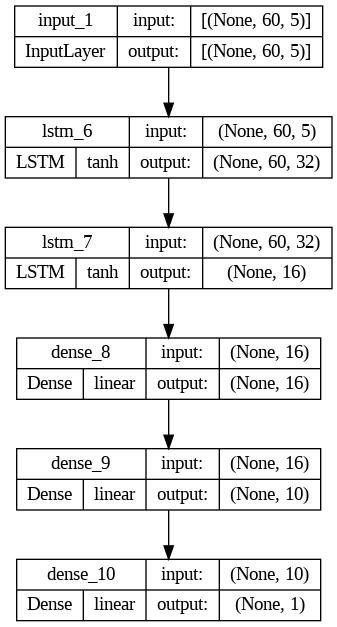

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(lstm_best, show_shapes=True, show_layer_activations=True, to_file='lstm_best_model.png')

In [ ]:
# early-stopping criterion
early_stop = EarlyStopping(monitor='val_loss', min_delta=1e-6, patience=30, verbose=4)
best_history = lstm_best.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=20000, callbacks=[early_stop])

Epoch 1/20000
32/32 [==============================] - 5s 31ms/step - loss: 0.0214 - root_mean_squared_error: 0.1464 - val_loss: 0.0026 - val_root_mean_squared_error: 0.0510
Epoch 2/20000
32/32 [==============================] - 0s 9ms/step - loss: 0.0030 - root_mean_squared_error: 0.0547 - val_loss: 3.4716e-04 - val_root_mean_squared_error: 0.0186
Epoch 3/20000
32/32 [==============================] - 0s 9ms/step - loss: 0.0023 - root_mean_squared_error: 0.0479 - val_loss: 3.3528e-04 - val_root_mean_squared_error: 0.0183
Epoch 4/20000
32/32 [==============================] - 0s 9ms/step - loss: 0.0022 - root_mean_squared_error: 0.0464 - val_loss: 6.3902e-04 - val_root_mean_squared_error: 0.0253
Epoch 5/20000
32/32 [==============================] - 0s 9ms/step - loss: 0.0020 - root_mean_squared_error: 0.0450 - val_loss: 2.8266e-04 - val_root_mean_squared_error: 0.0168
Epoch 6/20000
32/32 [==============================] - 0s 9ms/step - loss: 0.0018 - root_mean_squared_error: 0.0421 - 

In [ ]:
best_history.history.keys()

dict_keys(['loss', 'root_mean_squared_error', 'val_loss', 'val_root_mean_squared_error'])

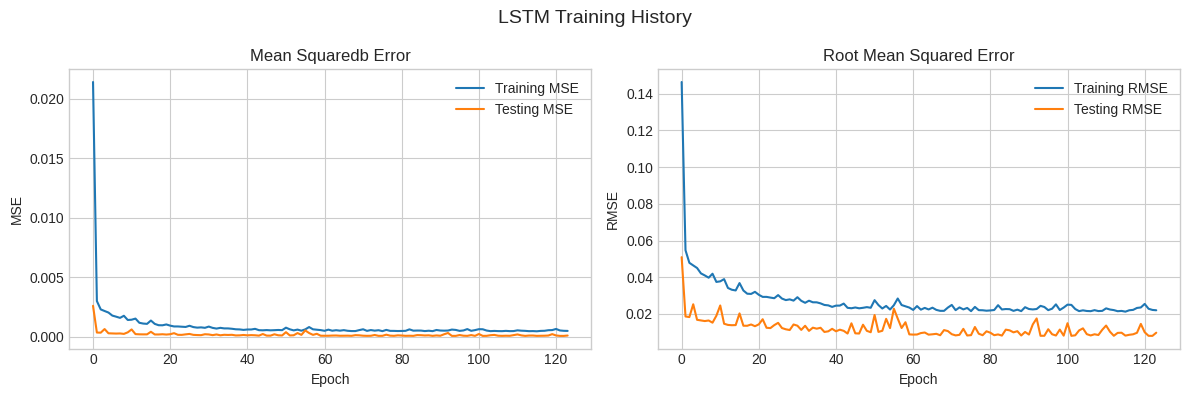

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(121)
plt.plot(best_history.history['loss'], label = "Training MSE")
plt.plot(best_history.history['val_loss'], label = "Testing MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Mean Squaredb Error")
plt.legend()

plt.subplot(122)
plt.plot(best_history.history['root_mean_squared_error'], label = "Training RMSE")
plt.plot(best_history.history['val_root_mean_squared_error'], label = "Testing RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Root Mean Squared Error")
plt.legend()
plt.suptitle("LSTM Training History", fontsize=14)
plt.tight_layout()

4/4 [==============================] - 0s 4ms/step


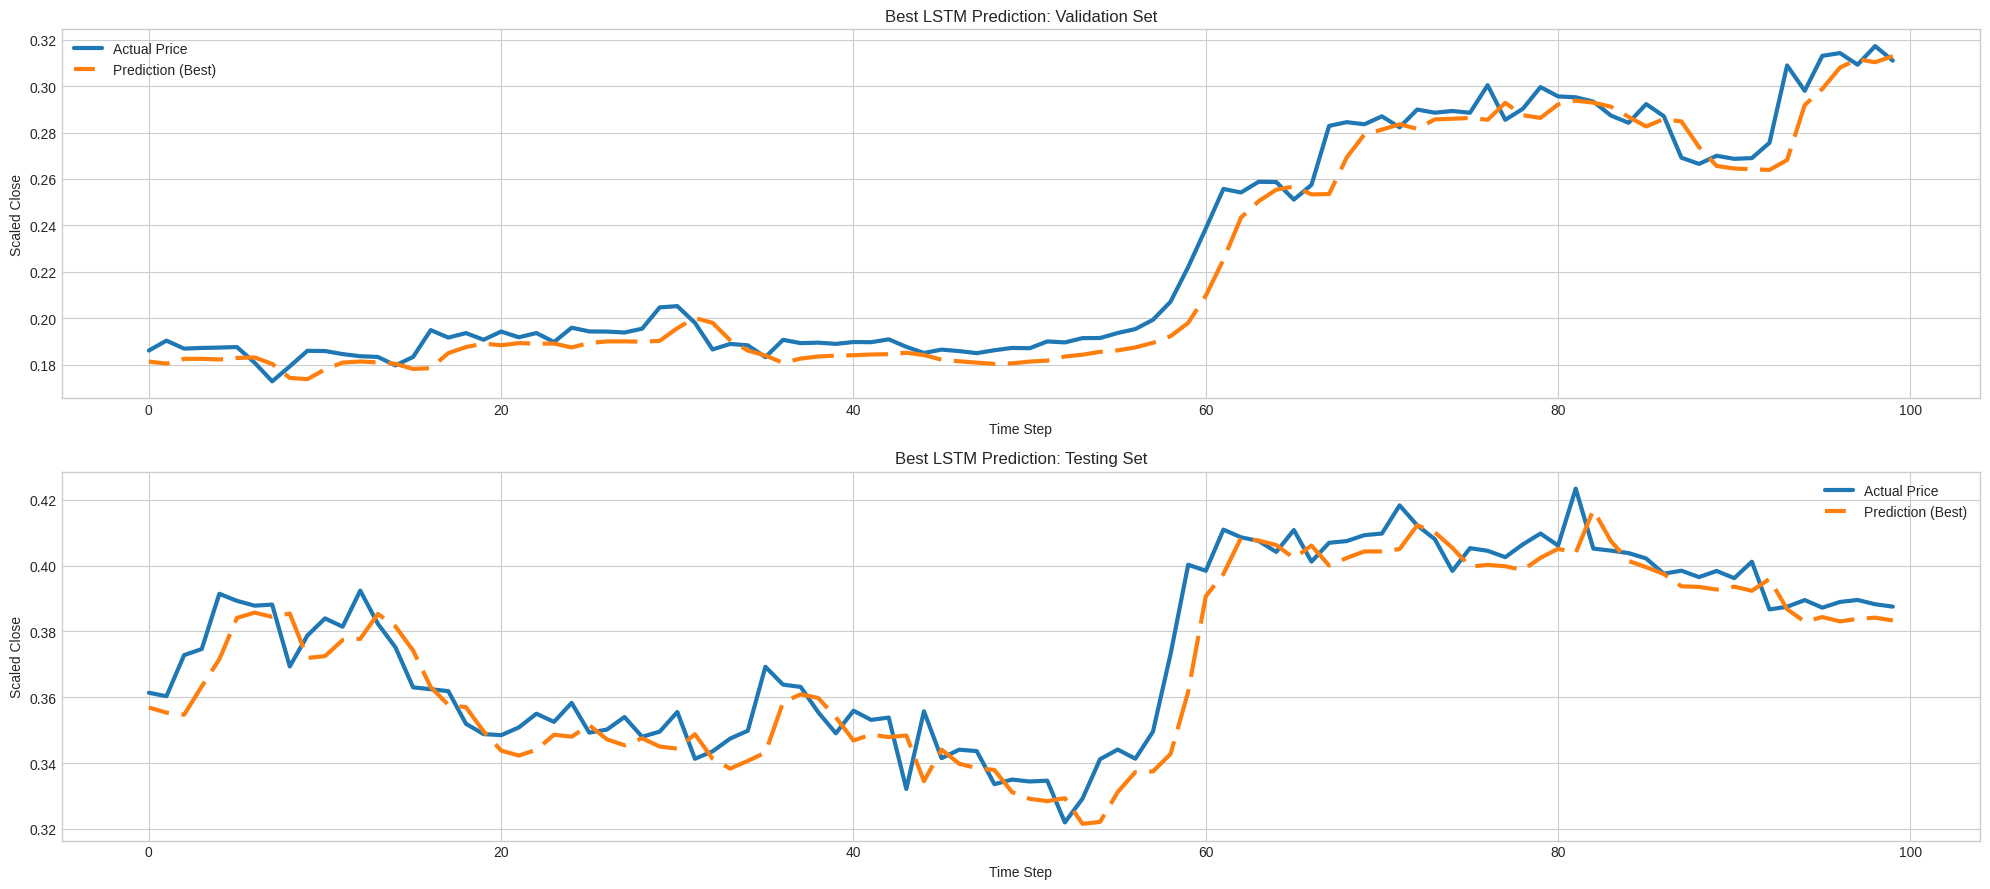

In [ ]:
plt.style.use("seaborn-whitegrid")
best_pred_valid = lstm_best.predict(X_valid)
best_pred_test = lstm_best.predict(X_test)

plt.figure(figsize=(20,9))

plt.subplot(211)
plt.plot(y_valid, label="Actual Price", linewidth=3)
plt.plot(best_pred_valid, label="Prediction (Best)", linestyle=(5,(10,3)), linewidth=3)
plt.legend()
plt.xlabel("Time Step")
plt.ylabel("Scaled Close")
plt.title("Best LSTM Prediction: Validation Set")

plt.subplot(212)
plt.plot(y_test, label="Actual Price", linewidth=3)
plt.plot(best_pred_test, label="Prediction (Best)", linestyle=(5,(10,3)), linewidth=3)
plt.legend()
plt.xlabel("Time Step")
plt.ylabel("Scaled Close")
plt.title("Best LSTM Prediction: Testing Set")

plt.tight_layout()

**Comment:**

Despite with optimized hyperparameters, the multi-feature LSTM model still exhibits a relative large time-lag in its predictions. We tend to get the correct short-term trend when the price is on a smooth climb. Nevertheless, when fluctuations are present, the model almost always outputs close prices from the nearest past, plus some small amount of negative bias. By applying early-stopping, we converged to a point very close to the local minimum, using only 124 epochs of training. In other words, adding more epochs of training would very unlikely bring any significant improvement to the model. In conclusion, the next-day prediction seems very challenging if using the current model structure and feature sets.

## Multi-Day Prediction

In reality, investors often tend to be more interested the direction that a company, industry, etc. is headed in the next few days or even in the long run. We also want to see whether we can forecast the changes in the price over a longer period of time. This motivates the multi-day prediction task. There are 2 possible approaches to doing this. The first approach is to change the last layer of our LSTM model, such that prices for a sequence of days rather than in the next day is given as the output. The second approach is to recursively perform next-day prediction for a desired number of times, each time based on the previous day's predicted closing price.



### Approach I: Change Model Output

Here we build a many-to-many LSTM model to predict the close price for the next 3 days. Indeed, many-to-many LSTM has many advanced variants, including Seq2Seq LSTM, Bidirectional LSTM ans such, which aim to model more complex relationship between the input and output sequences. In the simplest case that we consider, we keep the vanilla LSTM structure and simply change the size of the output layer to 3. We use the same set of parameters and hidden layers as before. Our goal here is to test whether the vanilla LSTM algorithm itself (without any fancy modification) will work in the financial time series prediction task.

To implement the change, we need to modify the input and output data dimensions and shapes. With the same trian-test split, we now only have 340 data for training (meaning that roughly 340 $\times$ 60 days of close price data), 33 data for validation (parameter updating) and 33 data for testing the real world performance of our many-to-many LSTM.

After training with 200 epochs, the training loss has already stablized, suggesting that at least we reached very close to a local minimum and should not add any additional training tasks. The prediction results are shown in the figure below. Here we took the first 16 predictions from the validation set. At immediate glance, one can notice that all predicted curves share a nearly identical shape. The only difference is in the intercept, which shifts the prediction curves up and down to "best fit" the actual prices. This again suggests that a simple many-to-many LSTM is not able to learn complex price behaviors. Instead, it likely has captured a "mean response", or to put it in another way, a common pattern of 3-day price change (such that the price drops first, then rises in the next day).

In [ ]:
# input_arr = np.array([X_valid[0]])

# input_seq = X_valid[0,:,:]

# for d in range(100):

#   prediction_input = np.array([input_seq[d:d+60]])
#   next_prediction = lstm_best.predict(prediction_input)
#   print(next_prediction)



In [ ]:
# plt.plot(input_seq[60:], label = "Predicted")
# plt.plot(y_valid[:100], label = "Actual")
# plt.title("Multi-day Prediction using Close Price")
# plt.legend()

In [ ]:
def get_Xy_multi(X_data, y_data, n, m):

  if len(X_data) != len(y_data): # X and y data should have same size
    raise ValueError("Incorrect input size!")

  cutoff_X = (X_data.shape[0] // m)*m
  cutoff_y = (y_data.shape[0] // m)*m
  X_data = X_data[:cutoff_X]
  y_data = y_data[:cutoff_y]

  X = []
  y = []

  for i in range(0, len(X_data)-n, m):
    X.append(np.array(X_data[i:i+n]))
    y.append(np.array(y_data[i+n:i+n+m]))



  print(np.array(X).shape)
  print(np.array(y).shape)
  # X = np.reshape(X, (X.shape[0], X.shape[1], 1)) # reshape X data to be fed into LSTM model

  return np.array(X), np.array(y)


In [ ]:
(btc_valid_Xy[:,-1].shape[0]//7)*7

154

In [ ]:
X_train, y_train = get_Xy_multi(X_data = btc_train_Xy[:,:-1], y_data = btc_train_Xy[:,-1], n=60, m=3) # last column as target, the others as input predictors
X_valid, y_valid = get_Xy_multi(X_data = btc_valid_Xy[:,:-1], y_data = btc_valid_Xy[:,-1], n=60, m=3)
X_test, y_test = get_Xy_multi(X_data = btc_test_Xy[:,:-1], y_data = btc_test_Xy[:,-1], n=60, m=3)

(340, 60, 5)
(340, 3)
(33, 60, 5)
(33, 3)
(33, 60, 5)
(33, 3)


In [ ]:
lstm_model00 = Sequential()
lstm_model00.add(LSTM(units = 128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
lstm_model00.add(LSTM(units = 64, return_sequences=True))
lstm_model00.add(LSTM(units = 32, return_sequences=False))
lstm_model00.add(Dense(25, activation='linear'))
lstm_model00.add(Dense(3, activation='linear'))


lstm_model00.summary()
lstm_model00.compile(optimizer = Adam(learning_rate=0.0003), loss = MeanSquaredError(), metrics=[RootMeanSquaredError()])

# history00 = lstm_model00.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=200)

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 60, 128)           68608     
                                                                 
 lstm_5 (LSTM)               (None, 60, 64)            49408     
                                                                 
 lstm_6 (LSTM)               (None, 32)                12416     
                                                                 
 dense_6 (Dense)             (None, 25)                825       
                                                                 
 dense_7 (Dense)             (None, 3)                 78        
                                                                 
Total params: 131335 (513.03 KB)
Trainable params: 131335 (513.03 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


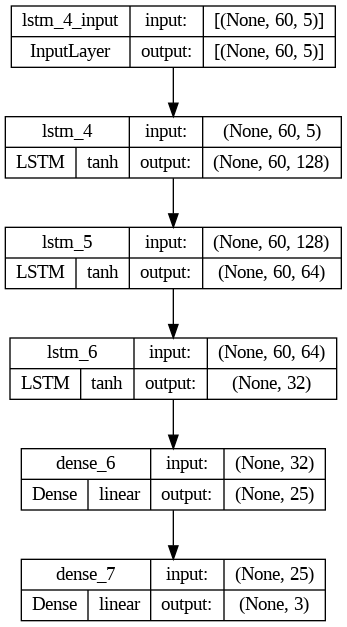

In [ ]:
plot_model(lstm_model00, show_shapes=True, show_layer_activations=True)

1/1 [==============================] - 1s 1s/step


1/1 [==============================] - 0s 32ms/step


1/1 [==============================] - 0s 32ms/step


1/1 [==============================] - 0s 29ms/step


1/1 [==============================] - 0s 31ms/step


...

1/1 [==============================] - 0s 31ms/step


1/1 [==============================] - 0s 32ms/step


1/1 [==============================] - 0s 34ms/step


1/1 [==============================] - 0s 31ms/step


1/1 [==============================] - 0s 32ms/step


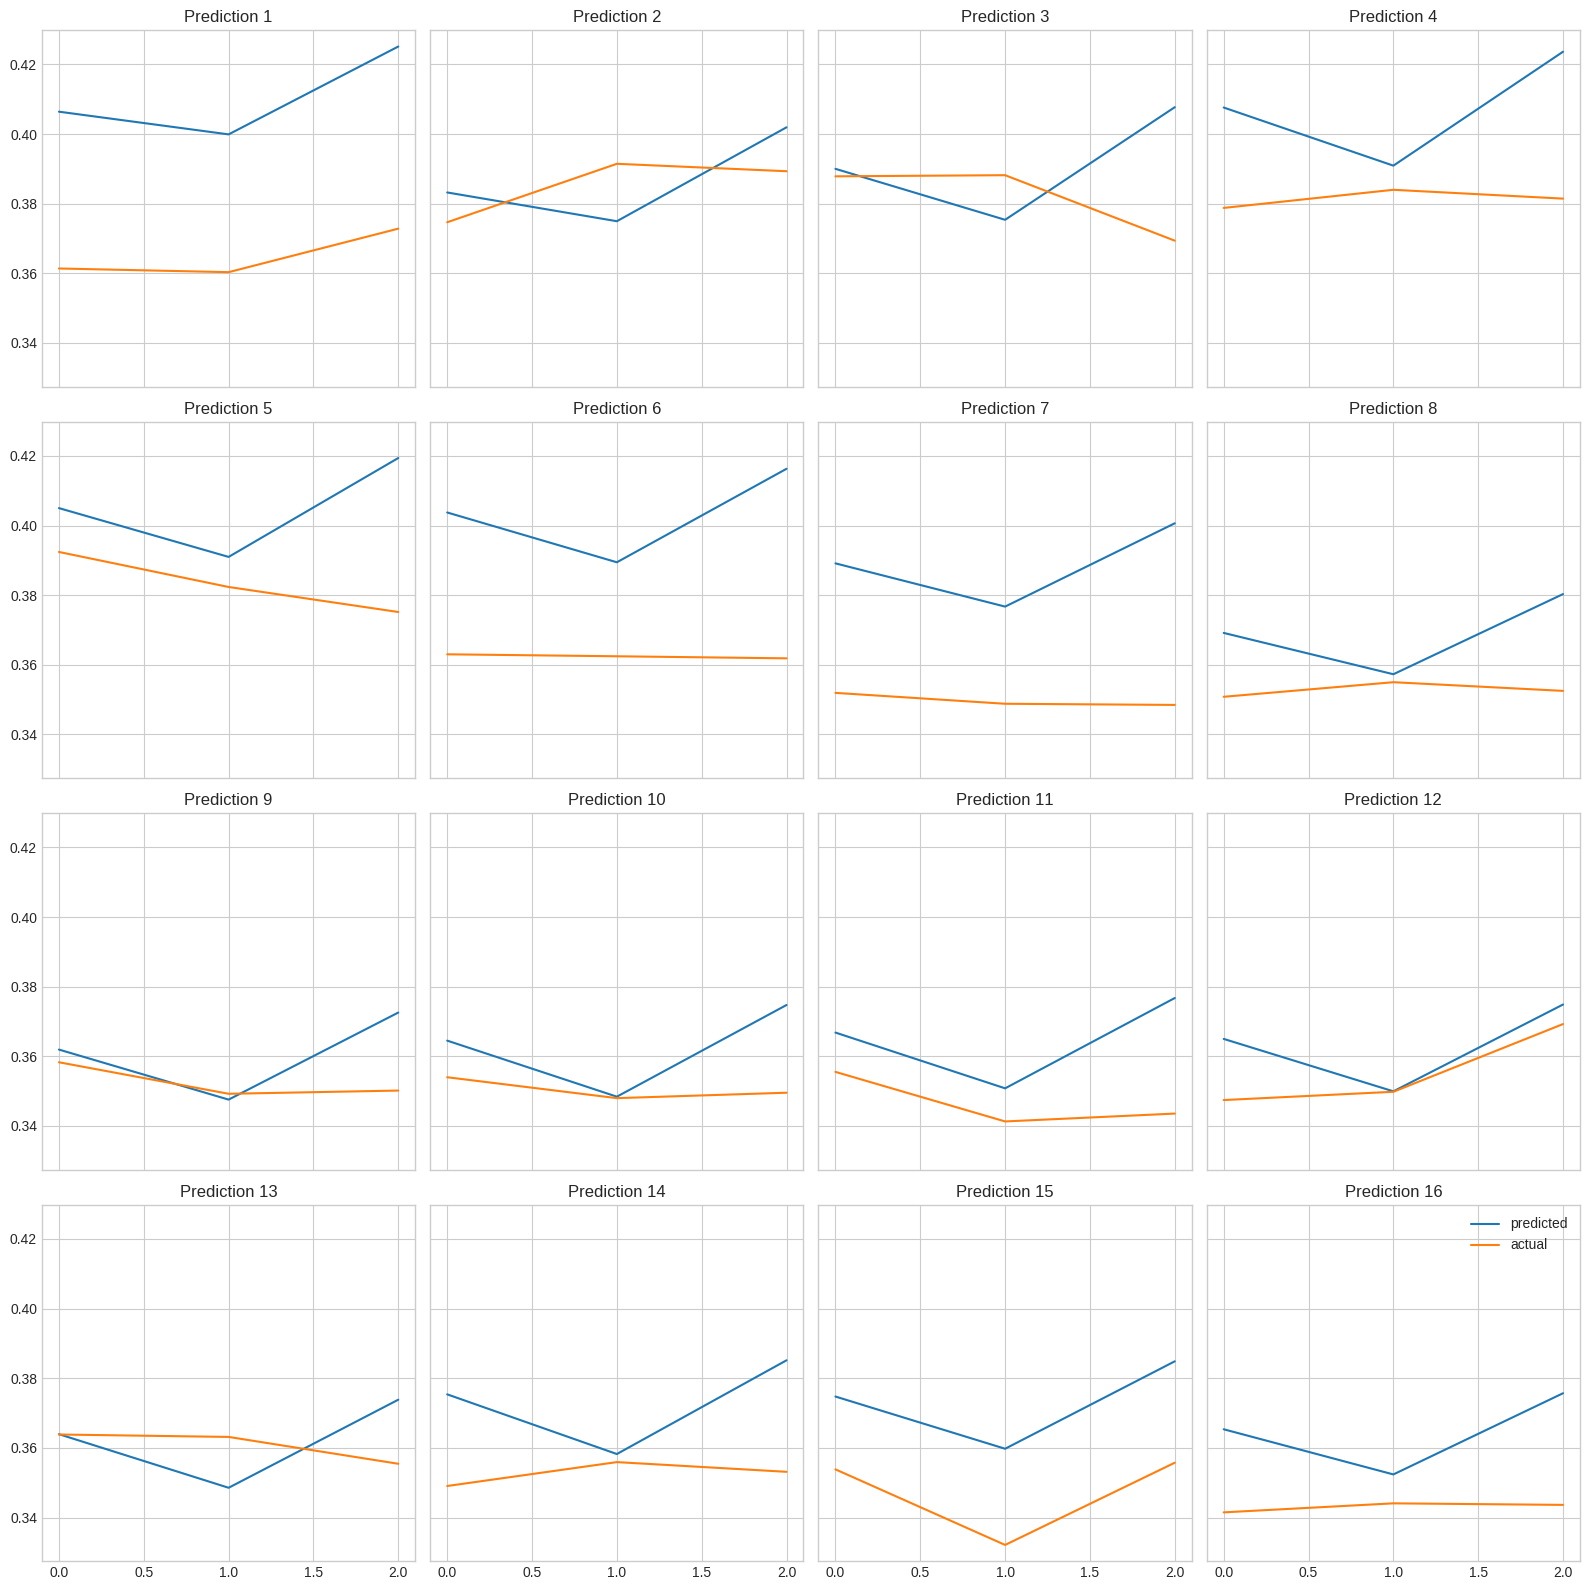

In [ ]:
fig, axs = plt.subplots(4, 4, figsize=(16, 16), sharex=True, sharey=True)

for i, ax in enumerate(axs.flatten()):

    pred = lstm_model00.predict(X_test[i].reshape((-1,60,5)))
    actual = y_test[i]
    ax.plot(pred[0], label="predicted")
    ax.plot(actual, label="actual")
    plt.legend()
    ax.set_title('Prediction {0}'.format(i+1))

plt.tight_layout()

plt.show()




### Approach II: Stateful LSTM

In [ ]:
def set_split2(data, test_size=100, valid_size=100, window_size=60, get_unused=False):

  N = data.shape[0]
  test_size += window_size # in addition to the 100 data, we need an additional 60 as input data
  valid_size += window_size

  test_set = data[N-test_size:]
  valid_set = data[N-valid_size-test_size+window_size:N-valid_size+window_size]
  train_set = data[:N-valid_size-test_size+window_size]

  return train_set, valid_set, test_set

In [ ]:
btc_train_Xy2, btc_valid_Xy2, btc_test_Xy2 = set_split2(coin_df['Close'][coin_df.name == "Bitcoin"])

# btc_train_Xy2.shape
# btc_valid_Xy2.shape
btc_test_Xy2.shape

# scale data using Min-Max scaler
# first fit a scaler on training data, then fit to testing and validation set

btc_scaler2 = MinMaxScaler(feature_range=(0,1))

btc_train_Xy2 = btc_scaler2.fit_transform(btc_train_Xy2.values.reshape(-1,1))
btc_valid_Xy2 = btc_scaler2.transform(btc_valid_Xy2.values.reshape(-1,1))
btc_test_Xy2 = btc_scaler2.transform(btc_test_Xy2.values.reshape(-1,1))



In [ ]:
X_train2, y_train2 = get_Xy(X_data = btc_train_Xy2, y_data = btc_train_Xy2, n=60)
X_valid2, y_valid2 = get_Xy(X_data = btc_valid_Xy2, y_data = btc_valid_Xy2, n=60)
X_test2, y_test2 = get_Xy(X_data = btc_test_Xy2, y_data = btc_test_Xy2, n=60)

(1141, 60, 1)
(100, 60, 1)
(100, 60, 1)


In [ ]:
stateful_lstm = Sequential()
stateful_lstm.add(LSTM(units = 128, return_sequences=True, stateful=True, batch_input_shape=(1, 1, 1)))
stateful_lstm.add(LSTM(units = 64, return_sequences=True, stateful=True))
stateful_lstm.add(LSTM(units = 32, return_sequences=False, stateful=True))
stateful_lstm.add(Dense(units = 1))

stateful_lstm.compile(optimizer=Adam(learning_rate=0.01), loss = MeanSquaredError(), metrics=[RootMeanSquaredError()])
stateful_lstm.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (1, 1, 128)               66560     
                                                                 
 lstm_1 (LSTM)               (1, 1, 64)                49408     
                                                                 
 lstm_2 (LSTM)               (1, 32)                   12416     
                                                                 
 dense (Dense)               (1, 1)                    33        
                                                                 
Total params: 128417 (501.63 KB)
Trainable params: 128417 (501.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
predicted = []
for epoch in range(1):
    mean_train_mse = []
    for i in range(len(X_train2)):
      print(i)
      y_true = y_train2[i]
      for j in range(60):
        tr_mse, tr_rmse = stateful_lstm.train_on_batch(X_train2[i][j].reshape(-1, 1, 1),
                                                       np.array([y_true]))
        mean_train_mse.append(tr_mse)

      stateful_lstm.reset_states()

    print('Training MSE on epoch {0} is {1}'.format(epoch, np.mean(mean_train_mse)))

    for i in range(len(X_valid2)):
      print('test '+str(i))
      for j in range(60):
        pred = stateful_lstm.predict_on_batch(X_valid2[i][j].reshape(-1, 1, 1))
        if j == 59:
          print('prediction made')
          print(pred)
          predicted.append(pred)

      stateful_lstm.reset_states()


    print('Testing MSE on epoch {0} is {1}'.format(epoch, np.mean(mean_test_mse)))

In [ ]:
predicted = []
for epoch in range(1):
    mean_train_mse = []
    for i in range(len(X_train2)):
      print(i)
      y_true = y_train2[i]
      for j in range(60):
        tr_mse, tr_rmse = stateful_lstm.train_on_batch(X_train2[i][j].reshape(-1, 1, 1),
                                                       np.array([y_true]))
        mean_train_mse.append(tr_mse)

      stateful_lstm.reset_states()

    print('Training MSE on epoch {0} is {1}'.format(epoch, np.mean(mean_train_mse)))

    for i in range(len(X_valid2)):
      print('pred '+str(i))
      for j in range(60):
        pred = stateful_lstm.predict_on_batch(X_valid2[i][j].reshape(-1, 1, 1))
        if j == 59:
          print('prediction made')
          print(pred)
          predicted.append(pred)

      stateful_lstm.reset_states()




In [ ]:
train_predicted = []
predicted = []

stateful_lstm.reset_states()

for i in range(len(X_train2)):
  for j in range(60):
    _ = stateful_lstm.predict_on_batch(X_train2[i][j].reshape(-1, 1, 1))
    train_predicted.append(_)

predicted.append(train_predicted[-1])

for i in range(len(X_valid2)):
  pred = stateful_lstm.predict_on_batch(predicted[i].reshape(1, 1, 1))
  predicted.append(pred)


In [ ]:
predicted_list = [arr[0][0] for arr in predicted]

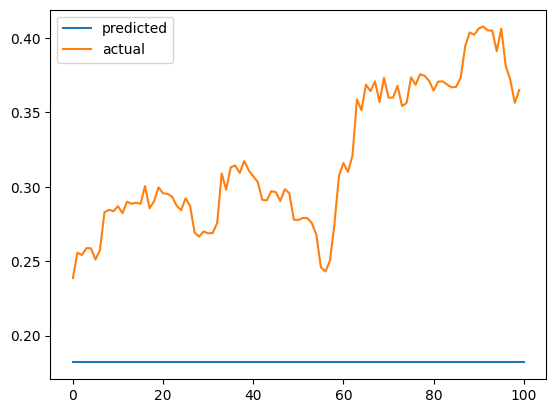

In [ ]:
plt.plot(predicted_list, label='predicted')
plt.plot(y_valid2, label='actual')
plt.legend()

### Comment

The stateful LSTM predicted a constant line. Obviously, it is incapable of making consecutive predictions, even with all the contexts provided from the last 60 days which were passed down one day at a time.

# Improvement